In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
data = pd.read_csv('../car_fuel_efficiency.csv')
df = data[['engine_displacement','horsepower','vehicle_weight','model_year',
            'fuel_efficiency_mpg']].copy()
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


## EDA

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


In [185]:
# Check missing
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [152]:
df.describe().round(2)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.00,8996.00,9704.00,9704.00,9704.00
mean,199.71,149.66,3001.28,2011.48,14.99
std,49.46,29.88,497.89,6.66,2.56
min,10.00,37.00,952.68,2000.00,6.20
25%,170.00,130.00,2666.25,2006.00,13.27
50%,200.00,149.00,2993.23,2012.00,15.01
75%,230.00,170.00,3334.96,2017.00,16.71
max,380.00,271.00,4739.08,2023.00,25.97


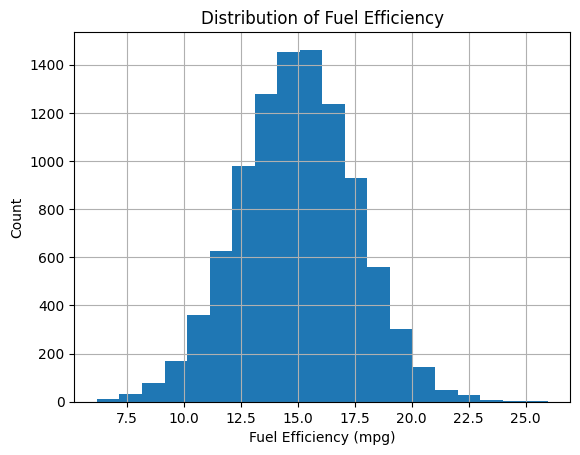

In [153]:
df['fuel_efficiency_mpg'].hist(bins=20)
plt.xlabel('Fuel Efficiency (mpg)')
plt.ylabel('Count')
plt.title('Distribution of Fuel Efficiency')
plt.show()

## Prepare and Split Dataset

In [154]:
# Set seed and shuffle data
seed = np.random.seed(42)

# Get the index positions
indices = df.index.to_numpy()

# Shuffle the indices
np.random.shuffle(indices)

# Reorder the DataFrame
df = df.iloc[indices].reset_index(drop=True)
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,220,144.0,2535.887591,2009,16.642943
1,160,141.0,2741.170484,2019,16.298377
2,230,155.0,2471.880237,2017,18.591822
3,150,206.0,3748.164469,2015,11.818843
4,300,111.0,2135.716359,2006,19.402209


In [155]:
# split 60%/20%/20% distribution
train, val, test = np.split(df, [int(np.ceil(.6 * len(df))), int(np.ceil(.8 * len(df)))])

c:\Users\asant\anaconda3\envs\pipenv\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


# Filling Missing Values with Zero

In [156]:
# Filling with Zero
ztrain = train.copy()
zval = val.copy()
ztest = test.copy()

ztrain['horsepower'] = ztrain['horsepower'].fillna(0)
zval['horsepower'] = zval['horsepower'].fillna(0)
ztest['horsepower'] = ztest['horsepower'].fillna(0)
ztrain.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

## Regression

In [157]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [158]:
y_train = ztrain['fuel_efficiency_mpg'].to_numpy()
X_train = ztrain.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_val = zval['fuel_efficiency_mpg'].to_numpy()
X_val = zval.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_test = ztest['fuel_efficiency_mpg'].to_numpy()
X_test = ztest.drop(columns=['fuel_efficiency_mpg']).to_numpy()

In [159]:
intercept, coefs = train_linear_regression(X_train, y_train)
print('Intercept:', intercept)
print('Coefficients:', coefs)

Intercept: 28.82142641185518
Coefficients: [ 9.92949593e-05  3.54212194e-03 -5.01324047e-03  3.45890933e-04]


In [160]:
y_pred = intercept + X_train.dot(coefs)
y_pred

array([17.33521745, 16.29295978, 17.69882512, ...,  9.93932414,
       17.54539863, 18.78279619])

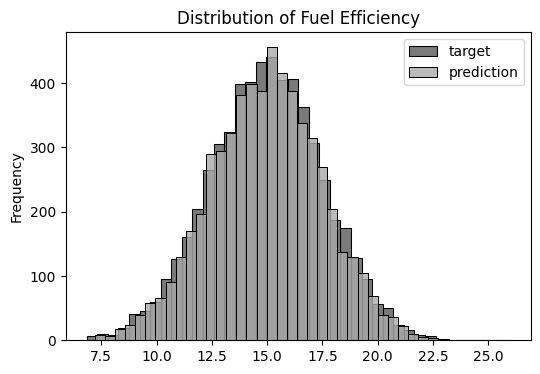

In [161]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('')
plt.title('Distribution of Fuel Efficiency')

plt.show()

In [162]:
# Calculate RMSE for training set
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [164]:
# Validation
y_val_pred = intercept + X_val.dot(coefs)
val_rmse = rmse(y_val, y_val_pred)
print(f'Validation RMSE: {round(val_rmse, 2)}')

Validation RMSE: 0.52


# Filling with mean

In [165]:
train.isnull().sum()
val.isnull().sum()
test.isnull().sum()

engine_displacement      0
horsepower             143
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [166]:
mtrain = train.copy()
mval = val.copy()
mtest = test.copy()

train_mean = mtrain['horsepower'].mean()
mtrain['horsepower'] = mtrain['horsepower'].fillna(train_mean)
mval['horsepower'] = mval['horsepower'].fillna(train_mean)
mtest['horsepower'] = mtest['horsepower'].fillna(train_mean)

In [167]:
y_train = mtrain['fuel_efficiency_mpg'].to_numpy()
X_train = mtrain.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_val = mval['fuel_efficiency_mpg'].to_numpy()
X_val = mval.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_test = mtest['fuel_efficiency_mpg'].to_numpy()
X_test = mtest.drop(columns=['fuel_efficiency_mpg']).to_numpy()

In [168]:
intercept, coefs = train_linear_regression(X_train, y_train)
print('Intercept:', intercept)
print('Coefficients:', coefs)

Intercept: 28.91814508530183
Coefficients: [ 0.00012085  0.01030302 -0.00501004 -0.00023116]


In [169]:
y_pred = intercept + X_train.dot(coefs)
y_pred

array([17.25905758, 16.19010965, 17.69242964, ...,  9.78513496,
       17.51664868, 18.77803122])

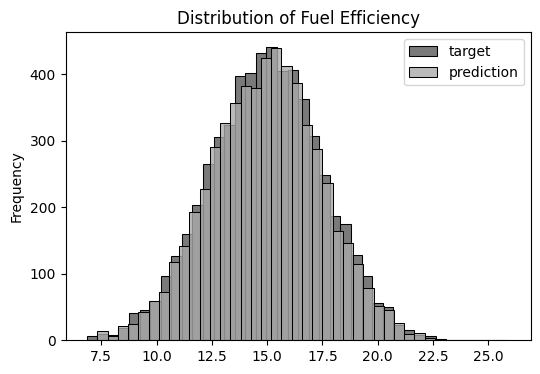

In [170]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('')
plt.title('Distribution of Fuel Efficiency')

plt.show()

In [171]:
train_rmse = rmse(y_train, y_pred)
print(f'Training RMSE: {round(train_rmse, 2)}')

Training RMSE: 0.46


In [172]:
# Validation
y_val_pred = intercept + X_val.dot(coefs)
val_rmse = rmse(y_val, y_val_pred)
print(f'Validation RMSE: {round(val_rmse, 2)}')

Validation RMSE: 0.46


## Regularization

In [173]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [174]:
y_train = ztrain['fuel_efficiency_mpg'].to_numpy()
X_train = ztrain.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_val = zval['fuel_efficiency_mpg'].to_numpy()
X_val = zval.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_test = ztest['fuel_efficiency_mpg'].to_numpy()
X_test = ztest.drop(columns=['fuel_efficiency_mpg']).to_numpy()

In [175]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
intercepts = []
coefs_list = []
y_val_pred = []
val_rmses = []

for r in r_values:
    intercept, coefs = train_linear_regression_reg(X_train, y_train, r)
    intercepts.append(intercept)
    coefs_list.append(coefs)

    y_val_pred = intercept + X_val.dot(coefs)
    val_rmses.append(rmse(y_val, y_val_pred))

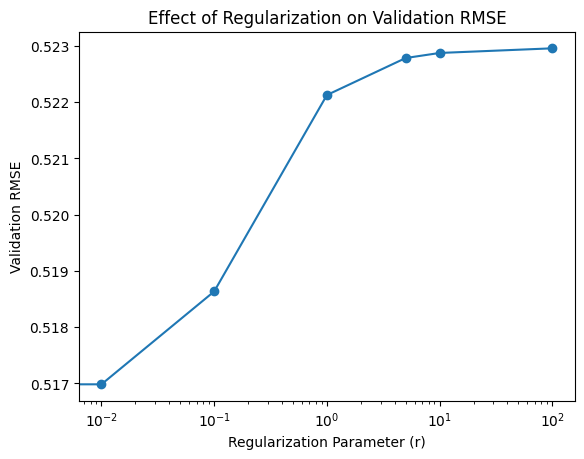

In [176]:
plt.plot(r_values, val_rmses, marker='o')
plt.xscale('log')
plt.xlabel('Regularization Parameter (r)')
plt.ylabel('Validation RMSE')
plt.title('Effect of Regularization on Validation RMSE')
plt.show() 

In [177]:
for r, rmse_val in zip(r_values, val_rmses):
    print(f'r: {r}, Validation RMSE: {round(rmse_val, 2)}')

r: 0, Validation RMSE: 0.52
r: 0.01, Validation RMSE: 0.52
r: 0.1, Validation RMSE: 0.52
r: 1, Validation RMSE: 0.52
r: 5, Validation RMSE: 0.52
r: 10, Validation RMSE: 0.52
r: 100, Validation RMSE: 0.52


In [186]:
seed_lists = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
all_rmse = []


for seed in seed_lists:

    # Set seed and shuffle data
    seed_num = np.random.seed(seed)

    # Get the index positions
    indices = df.index.to_numpy()

    # Shuffle the indices
    np.random.shuffle(indices)

    # Reorder the DataFrame
    df = df.iloc[indices].reset_index(drop=True)
    df.head()

    # split 60%/20%/20% distribution
    train, val, test = np.split(df, [int(np.ceil(.6 * len(df))), int(np.ceil(.8 * len(df)))])
    if seed == 0:
        print(train.info())

    train['horsepower'] = train['horsepower'].fillna(0)
    val['horsepower'] = val['horsepower'].fillna(0)
    test['horsepower'] = test['horsepower'].fillna(0)

    y_train = train['fuel_efficiency_mpg'].to_numpy()
    X_train = train.drop(columns=['fuel_efficiency_mpg']).to_numpy()

    y_val = val['fuel_efficiency_mpg'].to_numpy()
    X_val = val.drop(columns=['fuel_efficiency_mpg']).to_numpy()

    y_test = test['fuel_efficiency_mpg'].to_numpy()
    X_test = test.drop(columns=['fuel_efficiency_mpg']).to_numpy()

    # Train model without regularization
    intercept, coefs = train_linear_regression(X_train, y_train)

    # Evaluate on validation set
    y_val_pred = intercept + X_val.dot(coefs)
    rmse_val = rmse(y_val, y_val_pred)

    all_rmse.append(rmse_val)
    print(f'Seed: {seed}, Val RMSE: {round(rmse_val, 2)}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5823 entries, 0 to 5822
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  5823 non-null   int64  
 1   horsepower           5386 non-null   float64
 2   vehicle_weight       5823 non-null   float64
 3   model_year           5823 non-null   int64  
 4   fuel_efficiency_mpg  5823 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 227.6 KB
None
Seed: 0, Val RMSE: 0.51
Seed: 1, Val RMSE: 0.53
Seed: 2, Val RMSE: 0.52
Seed: 3, Val RMSE: 0.53
Seed: 4, Val RMSE: 0.52
Seed: 5, Val RMSE: 0.52
Seed: 6, Val RMSE: 0.52
Seed: 7, Val RMSE: 0.52
Seed: 8, Val RMSE: 0.52
Seed: 9, Val RMSE: 0.53


c:\Users\asant\anaconda3\envs\pipenv\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\asant\anaconda3\envs\pipenv\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\asant\anaconda3\envs\pipenv\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\asant\anaconda3\envs\pipenv\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users

In [187]:
np.std(all_rmse)

0.005987996637861963

In [189]:
# Set seed and shuffle data
seed_num = np.random.seed(9)

# Get the index positions
indices = df.index.to_numpy()

# Shuffle the indices
np.random.shuffle(indices)

# Reorder the DataFrame
df = df.iloc[indices].reset_index(drop=True)
df.head()

# split 60%/20%/20% distribution
train, test = np.split(df, [int(np.ceil(.8 * len(df)))])

# Print lengths
print(len(train), len(test))

train['horsepower'] = train['horsepower'].fillna(0)
test['horsepower'] = test['horsepower'].fillna(0)

y_train = train['fuel_efficiency_mpg'].to_numpy()
X_train = train.drop(columns=['fuel_efficiency_mpg']).to_numpy()

y_test = test['fuel_efficiency_mpg'].to_numpy()
X_test = test.drop(columns=['fuel_efficiency_mpg']).to_numpy()

# Train model without regularization
intercept, coefs = train_linear_regression_reg(X_train, y_train, r=.001)

# Evaluate on validation set
y_test_pred = intercept + X_test.dot(coefs)

rmse_val = rmse(y_test, y_test_pred)
print(f'Seed: {seed}, Test RMSE: {round(rmse_val, 5)}')

7764 1940
Seed: 9, Test RMSE: 0.51522


c:\Users\asant\anaconda3\envs\pipenv\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
